In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import csv

np.random.seed(2612)

In [2]:
def euclidean_projection_simplex(v):
    """Projeção no simplex {x >= 0, sum x = 1}"""
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.where(u > (cssv - 1) / (np.arange(len(v)) + 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1)
    return np.maximum(v - theta, 0)

def bregman_projection_simplex(v):
    return v/v.sum()

In [3]:
def gradient_descent(x0, eta=1e-2, max_iter=100):
    x = x0.copy()

    cumulated = x
    
    points = [x]
    means  = [x]
    times  = [0]
    dists  = [f(x)-f_opt]
    dists_means = [f(x)-f_opt]

    start_time = time.perf_counter()
    for i in range(max_iter):
        x -= eta* grad_f(x)
        x = euclidean_projection_simplex(x)
        cumulated += x
        if i % 4 == 0:
            elapsed_time = time.perf_counter() - start_time
            points.append(x)
            means.append(cumulated/(i+2))
            times.append(elapsed_time)
            dists.append(f(x)-f_opt)
            dists_means.append(f(cumulated/(i+2))-f_opt)
        filled_length = int(round(50 * i / max_iter))
        bar = '[' + '+' * filled_length + '-' * (50 - filled_length) + ']'
        print('\r' + bar, end='', flush=True)
    return points, means, times, dists, dists_means

def accelerated_gradient_descent(x0, eta=1e-2, max_iter=100):
    x = x0.copy()
    y = x.copy()
    k = 1

    cumulated = x
    
    points = [x]
    means  = [x]
    times  = [0]
    dists  = [f(x)-f_opt]
    dists_means = [f(x)-f_opt]

    start_time = time.perf_counter()
    for i in range(max_iter):
        x_old = x.copy()
        x = y - eta * grad_f(y)
        x = euclidean_projection_simplex(x)
        y = x + ((k - 1) / (k + 2)) * (x - x_old)
        k += 1
        cumulated += x
        if i % 4 == 0:
            elapsed_time = time.perf_counter() - start_time
            points.append(x)
            means.append(cumulated/(i+2))
            times.append(elapsed_time)
            dists.append(f(x)-f_opt)
            dists_means.append(f(cumulated/(i+2))-f_opt)
        
        filled_length = int(round(50 * i / max_iter))
        bar = '[' + '+' * filled_length + '-' * (50 - filled_length) + ']'
        print('\r' + bar, end='', flush=True)
    return points, means, times, dists, dists_means

def mirror_descent(x0, eta=1e-1, max_iter=100):
    x = x0.copy()

    cumulated = x
    
    points = [x]
    means  = [x]
    times  = [0]
    dists  = [f(x)-f_opt]
    dists_means = [f(x)-f_opt]
    
    start_time = time.perf_counter()
    for i in range(max_iter):
        multiplicative_gradient_step =  np.exp(-eta*grad_f(x))
        x = np.multiply(x, multiplicative_gradient_step)
        x =  bregman_projection_simplex(x)
        cumulated += x
        if i % 4 == 0:
            elapsed_time = time.perf_counter() - start_time
            points.append(x)
            means.append(cumulated/(i+2))
            times.append(elapsed_time)
            dists.append(f(x)-f_opt)
            dists_means.append(f(cumulated/(i+2))-f_opt)
        
        filled_length = int(round(50 * i / max_iter))
        bar = '[' + '+' * filled_length + '-' * (50 - filled_length) + ']'
        print('\r' + bar, end='', flush=True)
    return points, means, times, dists, dists_means

def accelerated_mirror_descent(x0, eta=1e-1, max_iter=100):
    x0 = x0.copy()
    x1 = x0.copy()
    k = 1
    
    cumulated = x0
    
    points = [x0]
    means  = [x0]
    times  = [0]
    dists  = [f(x0)-f_opt]
    dists_means = [f(x0)-f_opt]

    start_time = time.perf_counter()
    for i in range(max_iter):
        multiplicative_prediction_step = np.divide(x1, x0 + non_zero)**((k - 1) / (k + 2))
        x2 = np.multiply(x1, multiplicative_prediction_step)
        k += 1
        multiplicative_gradient_step =  np.exp(-eta*grad_f(x1))
        x2 = np.multiply(x2, multiplicative_gradient_step)
        x2 =  bregman_projection_simplex(x2)
        x0 = x1
        x1 = x2

        cumulated += x1
        if i % 4 == 0:
            elapsed_time = time.perf_counter() - start_time
            points.append(x1)
            means.append(cumulated/(i+2))
            times.append(elapsed_time)
            dists.append(f(x1)-f_opt)
            dists_means.append(f(cumulated/(i+2))-f_opt)
        filled_length = int(round(50 * i / max_iter))
        bar = '[' + '+' * filled_length + '-' * (50 - filled_length) + ']'
        print('\r' + bar, end='', flush=True)
    return points, means, times, dists, dists_means

In [4]:
def gera_tm_dt(mean, log, n,
               tm_gd, dt_gd,
               tm_agd, dt_agd,
               tm_md, dt_md,
               tm_amd, dt_amd,
               bound_gd=None, bound_md=None):
    plt.figure(figsize=(10,6))

    # Linhas principais
    plt.plot(tm_gd , dt_gd , 'o-', color="gold", label='GD')
    plt.plot(tm_agd, dt_agd, 'D-', color="orangered", label='AGD')
    plt.plot(tm_md , dt_md , 'o-', color="deepskyblue", label='MD')
    plt.plot(tm_amd, dt_amd, 'D-', color="slateblue", label='AMD')

    # Bounds (se fornecidos)
    if bound_gd is not None:
        plt.axhline(y=bound_gd, color="gold", linestyle="--", linewidth=1.5, label="Bound GD")
    if bound_md is not None:
        plt.axhline(y=bound_md, color="deepskyblue", linestyle="--", linewidth=1.5, label="Bound MD")

    # Escalas
    plt.xlabel(r'$t_k$')
    if log == 'log':
        plt.yscale('log')
        escala = ' (escala log)'
        str1 = '_log'
    elif log == 'symlog':
        plt.yscale('symlog', linthresh=1e-1)
        escala = ' (escala symlog)'
        str1 = '_symlog'
    else:
        escala = ''
        str1 = ''

    if mean:
        var = r'$x_k$'
        str2 = ' das médias'
        str3 = '_medias'
    else:
        var = r'\bar{X}_k'
        str2 = ''
        str3 = ''
    plt.ylabel(fr'$f({var})-f^*$'+escala)
    plt.title('Convergência'+str2+f' dos métodos em dimensão {n}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
    plt.tight_layout(pad=2.0)
    plt.savefig('imagens_dissertação/convergências_empíricas/comparacao_convergencias'+str3+str1+f'_dim{n}.pdf', 
                dpi=300, 
                bbox_inches='tight')
    #plt.close()  # Fecha a figura para liberar memória

In [5]:
def gera_dt(n, dt_gd, dt_agd, dt_md, dt_amd):
    plt.figure(figsize=(10,6))
    plt.plot(dt_gd , '-', color="gold", label='GD')
    
    plt.plot(dt_agd, '-', color="orangered", label='AGD')
    
    plt.plot(dt_md , '-', color="deepskyblue", label='MD')
    
    plt.plot(dt_amd, '-', color="slateblue", label='AMD')
    #plt.yscale('log')
    #plt.xscale('log')
    plt.xlabel('Iteração')
    plt.ylabel(r'$f(x)-f^*$')
    plt.title('Convergência dos métodos')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    #plt.show()
    
    plt.tight_layout(pad=2.0)
    plt.savefig(f"imagens_dissertação/2comparacao_convergencias_dim{n}.pdf", 
                dpi=300, 
                bbox_inches='tight')
    #plt.close()

In [6]:
def gera_tm(n, tm_gd, tm_agd, tm_md, tm_amd):
    plt.figure(figsize=(10,6))
    plt.plot(tm_gd,  '-', color="gold", label='GD')
    
    plt.plot(tm_agd, '-', color="orangered", label='AGD')
    
    plt.plot(tm_md,  '-', color="deepskyblue", label='MD')
    
    plt.plot(tm_amd, '-', color="slateblue", label='AMD')
    
    #plt.yscale('log')
    #plt.xscale('log')
    plt.xlabel('Iteração')
    plt.ylabel('Tempo de processamento')
    plt.title('Tempo de processamento dos métodos')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    #plt.show()
    
    plt.tight_layout(pad=2.0)
    plt.savefig(f"imagens_dissertação/3comparacao_convergencias_dim{n}.pdf", 
                dpi=300, 
                bbox_inches='tight')
    #plt.close()

In [7]:
def gera_todas_as_imgs_comparação(n, num_iter, x0, G2, Ginf):
    eta_gd =  eta*np.sqrt((n-1)/(n*num_iter))/(2*G2) # eta*1/L #eta*1/np.sqrt(L)
    eta_agd = eta_gd
    
    eta_md = eta**np.sqrt(np.log(n)/(2*num_iter))/Ginf #eta*np.sqrt(1/num_iter)
    eta_amd = eta_md

    bound_gd = 2*G2 * np.sqrt(((n-1)/(2*n)) * (2/num_iter))
    bound_md = 2*Ginf*np.sqrt( (np.log(n))  * (2/num_iter))

    print(fr"$\eta$ para GD e AGD: {eta_gd}")
    print(fr"$\eta$ para MD e AMD: {eta_md}")
    
    print()
    print('rodando GD')
    x_gd, xm_gd, tm_gd, dt_gd, dtm_gd = gradient_descent(x0, eta_gd, num_iter)
    
    print()
    print('rodando AGD')
    x_agd, xm_agd, tm_agd, dt_agd, dtm_agd  = accelerated_gradient_descent(x0, eta_agd, num_iter)
    
    print()
    print('rodando MD')
    x_md, xm_md, tm_md, dt_md, dtm_md   = mirror_descent(x0, eta_md, num_iter)
    
    print()
    print('rodando AMD')
    x_amd, xm_amd, tm_amd, dt_amd, dtm_amd  = accelerated_mirror_descent(x0, eta_amd, num_iter)

    return [[eta_gd, eta_md, bound_gd, bound_md],[x_gd, xm_gd, tm_gd, dt_gd, dtm_gd],[x_agd, xm_agd, tm_agd, dt_agd, dtm_agd],[x_md, xm_md, tm_md, dt_md, dtm_md], [x_amd, xm_amd, tm_amd, dt_amd, dtm_amd]]

dimensão 10

Constante de Lipschitz para GD: 335.16298916232427
Constante de Lipschitz para MD: 236.8761573132401
$\eta$ para GD e AGD: 1.0007375738689468e-05
$\eta$ para MD e AMD: 0.0035449269844820934

rodando GD
[++++++++++++++++++++++++++++++++++++++++++++++++++]
rodando AGD
[++++++++++++++++++++++++++++++++++++++++++++++++++]
rodando MD
[++++++++++++++++++++++++++++++++++++++++++++++++++]
rodando AMD
[++++++++++++++++++++++++++++++++++++++++++++++++++]

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.



dimensão 100

Constante de Lipschitz para GD: 517.3900115155478
Constante de Lipschitz para MD: 286.43345313231896
$\eta$ para GD e AGD: 6.799149078203379e-06
$\eta$ para MD e AMD: 0.002726954928826145

rodando GD
[++++++++++++++++++++++++++++++++++++++++++++++++++]
rodando AGD
[++++++++++++++++++++++++++++++++++++++++++++++++++]
rodando MD
[++++++++++++++++++++++++++++++++++++++++++++++++++]
rodando AMD
[++++++++++++++++++++++++++++++++++++++++++++++++++]
dimensão 1000

Constante de Lipschitz para GD: 1105.6879489715102
Constante de Lipschitz para MD: 319.0202647610193
$\eta$ para GD e AGD: 3.1959882533801383e-06
$\eta$ para MD e AMD: 0.002316160680173267

rodando GD
[++++++++++++++++++++++++++++++++++++++++++++++++++]
rodando AGD
[++++++++++++++++++++++++++++++++++++++++++++++++++]
rodando MD
[++++++++++++++++++++++++++++++++++++++++++++++++++]
rodando AMD
[++++++++++++++++++++++++++++++++++++++++++++++++++]
dimensão 10000

Constante de Lipschitz para GD: 3346.2854729067944
Constant

C:\Users\josea\AppData\Local\Temp\ipykernel_4584\1973402687.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,6))


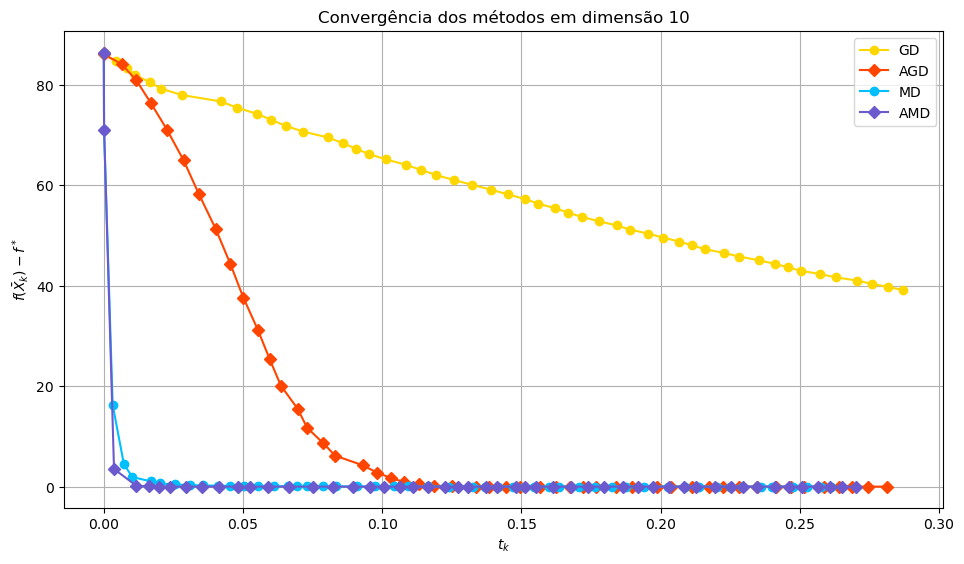

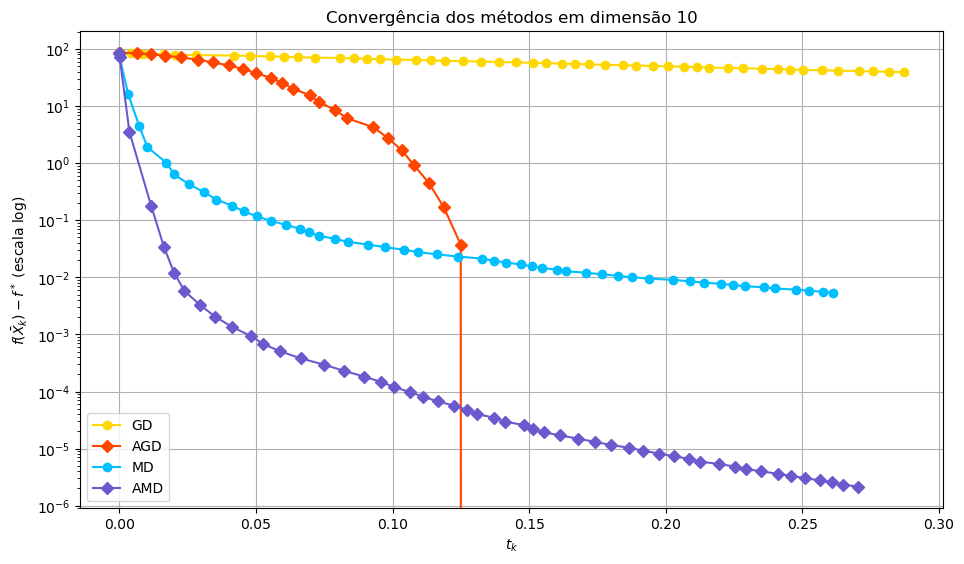

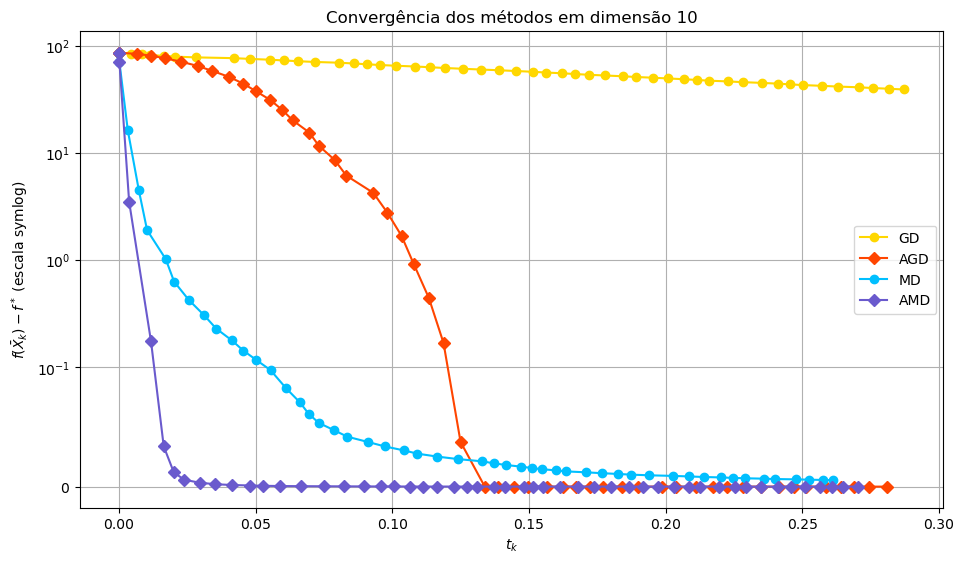

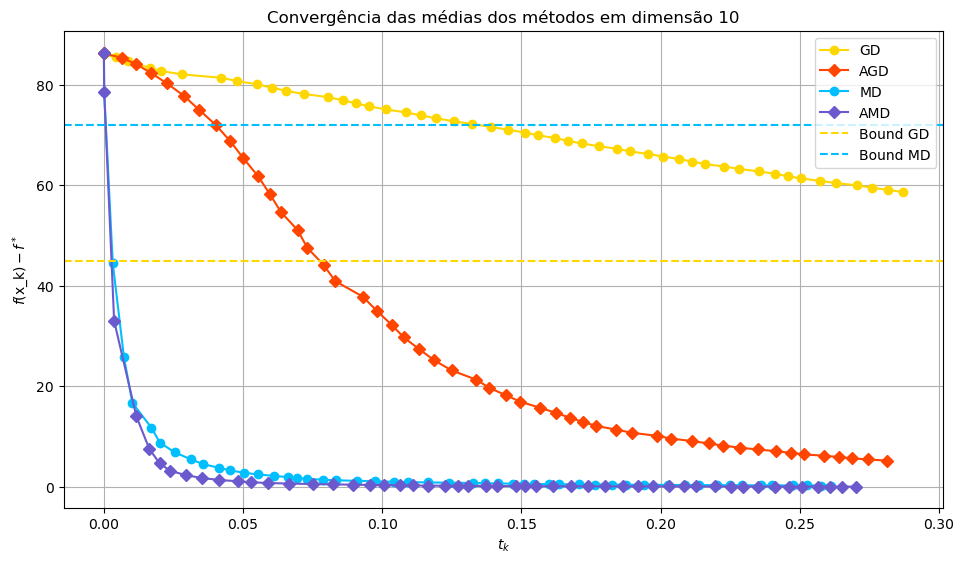

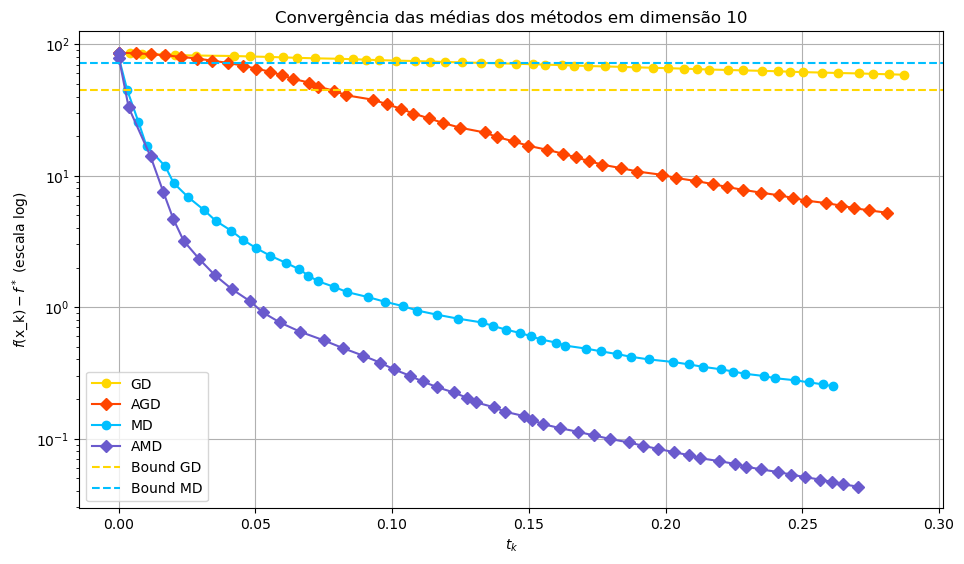

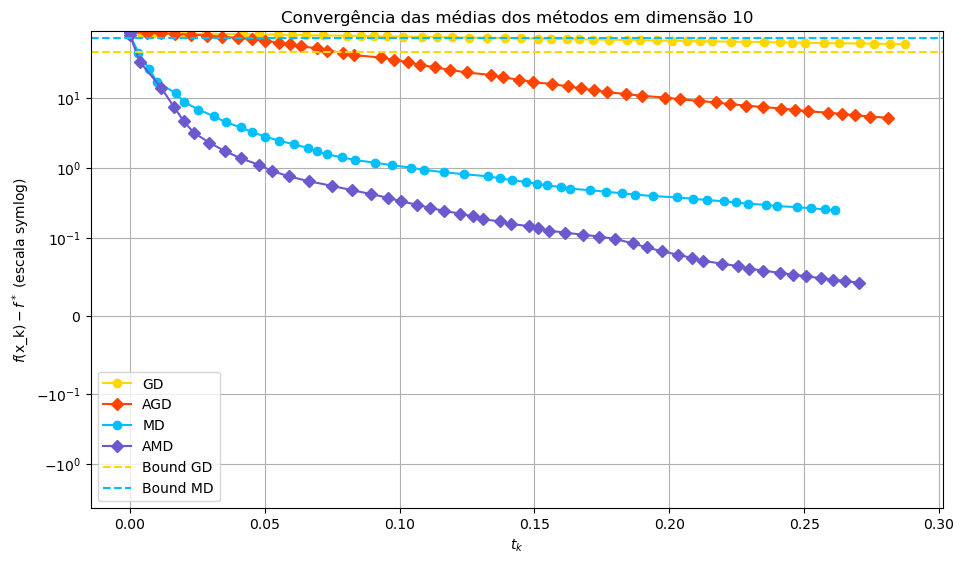

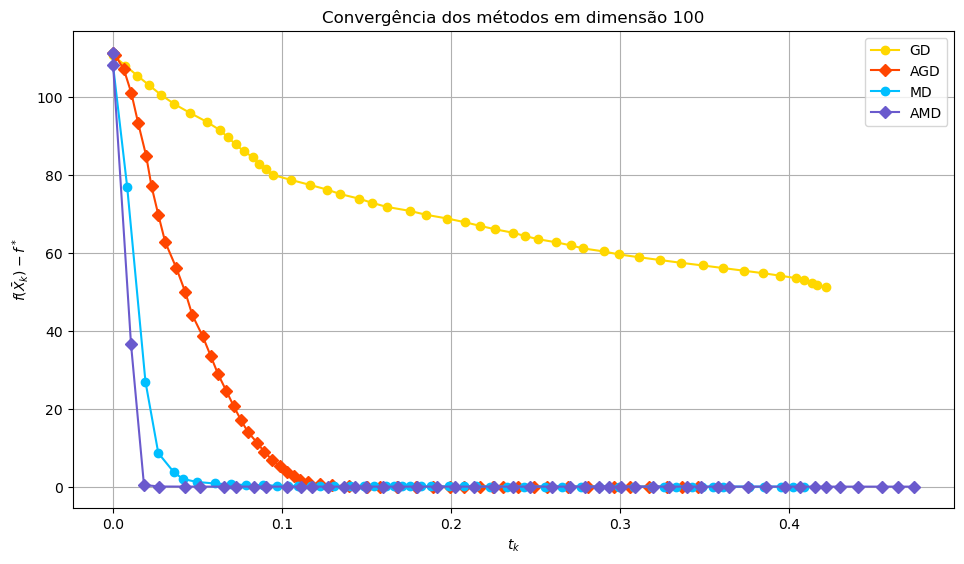

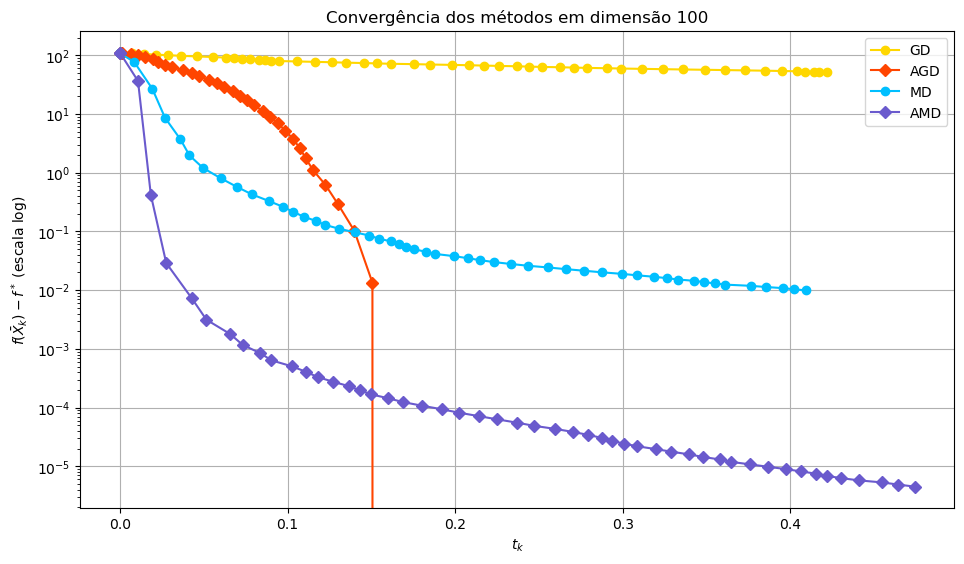

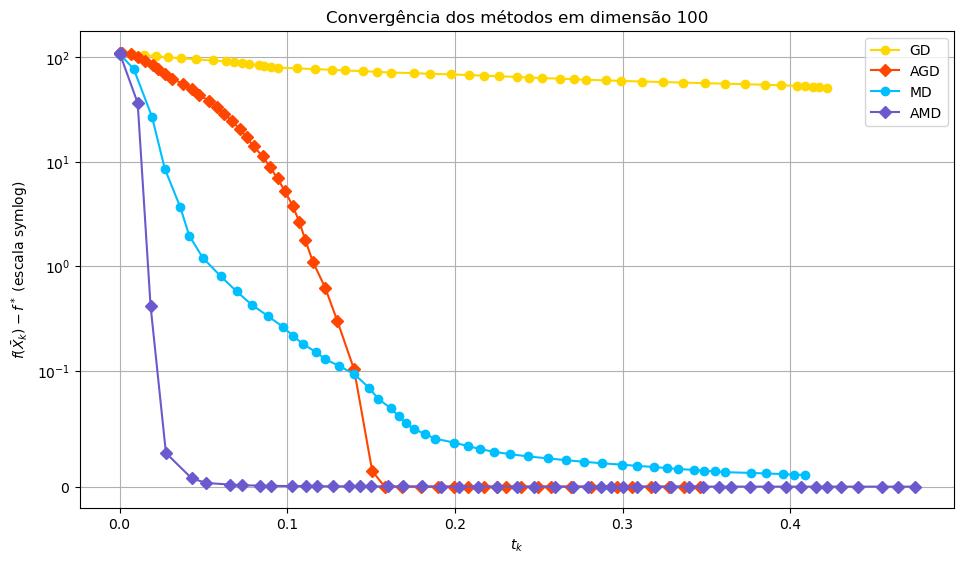

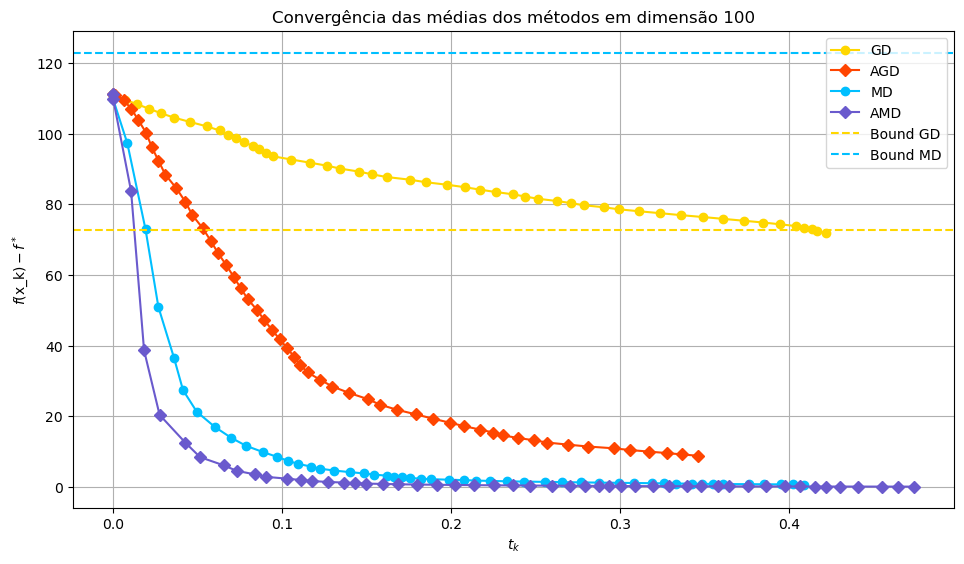

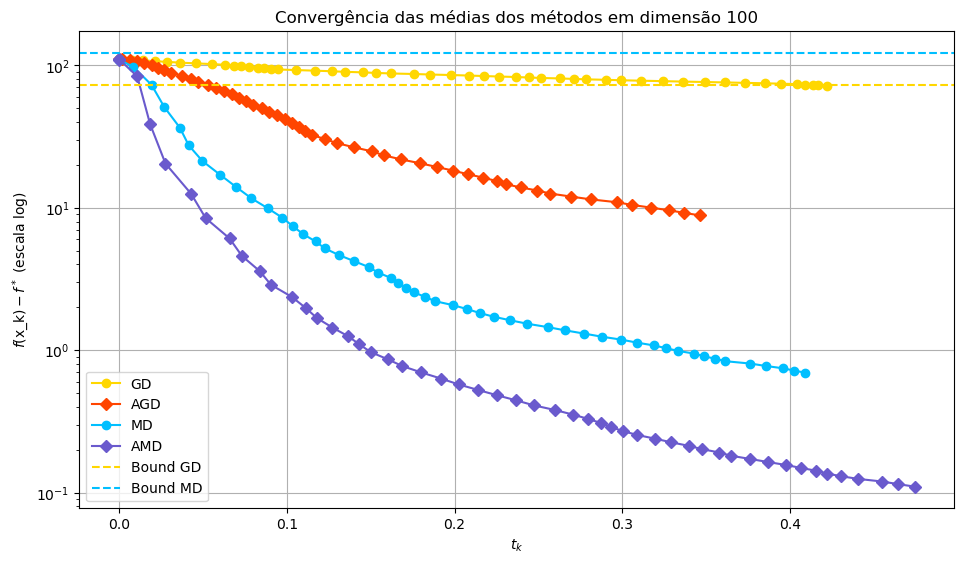

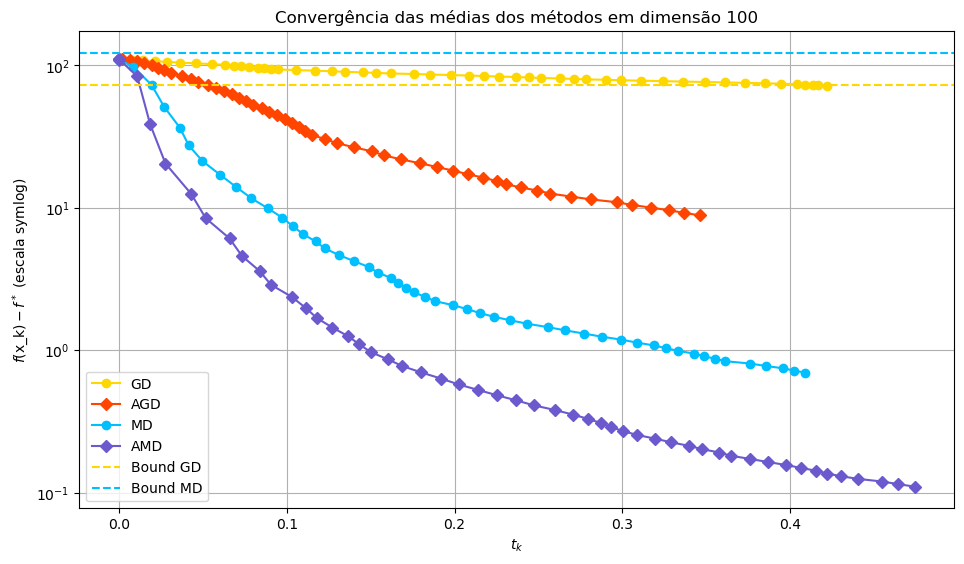

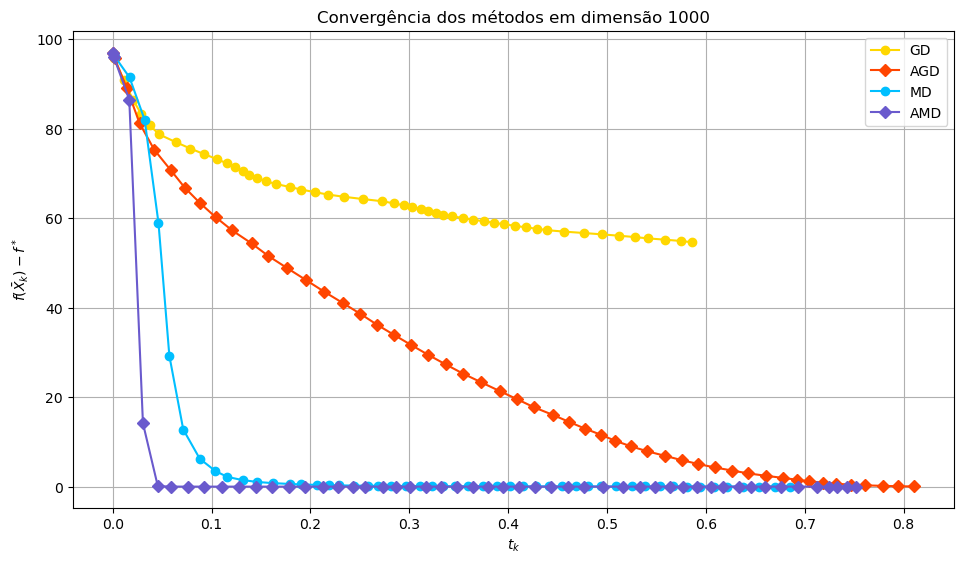

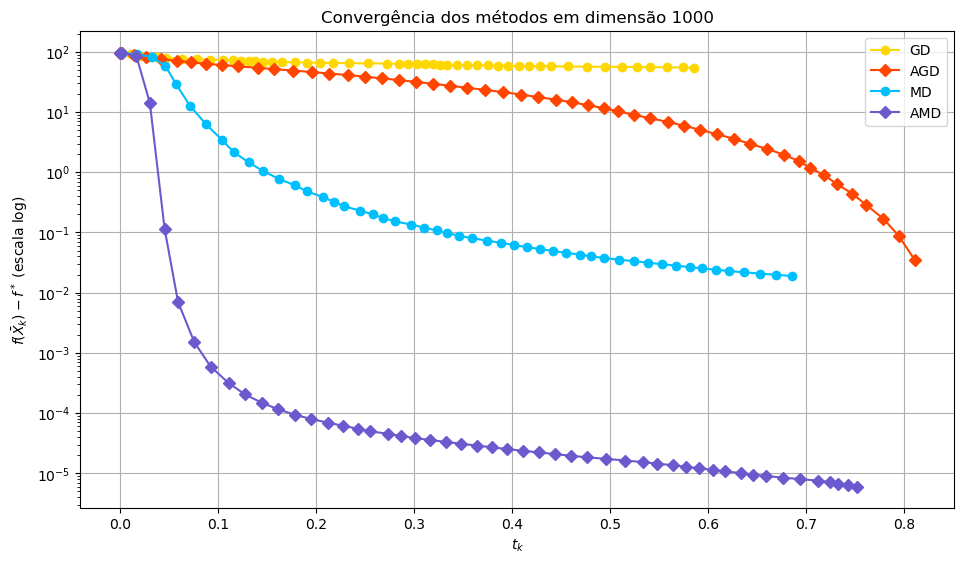

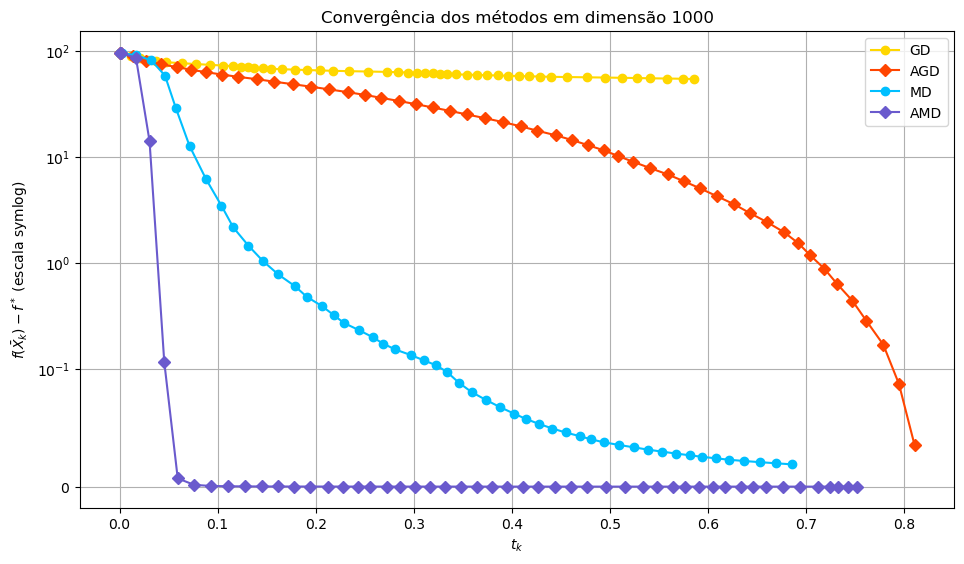

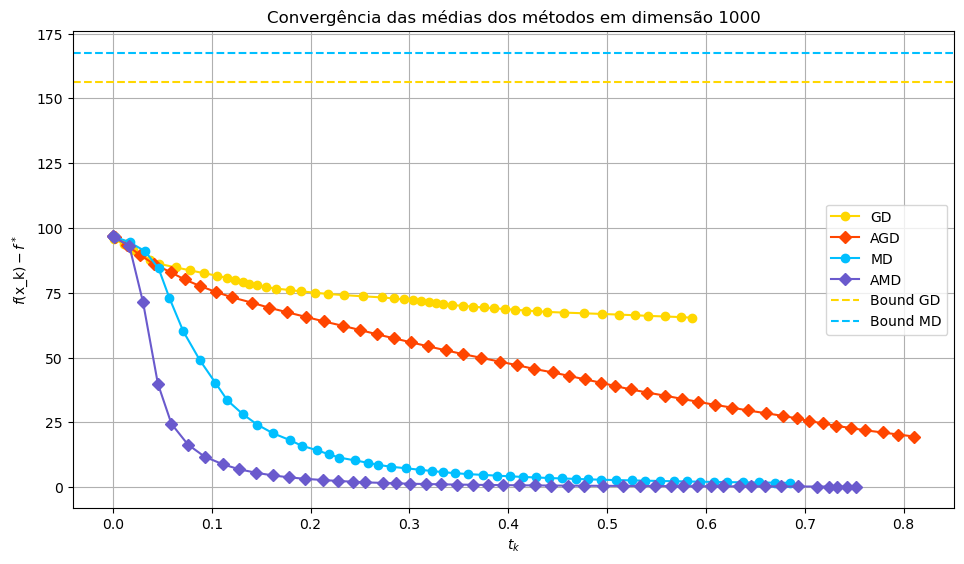

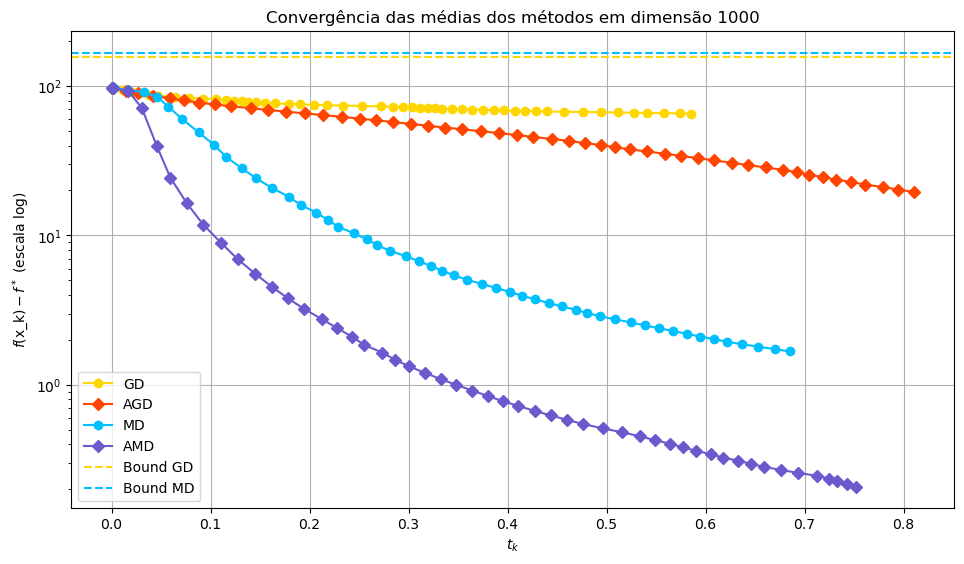

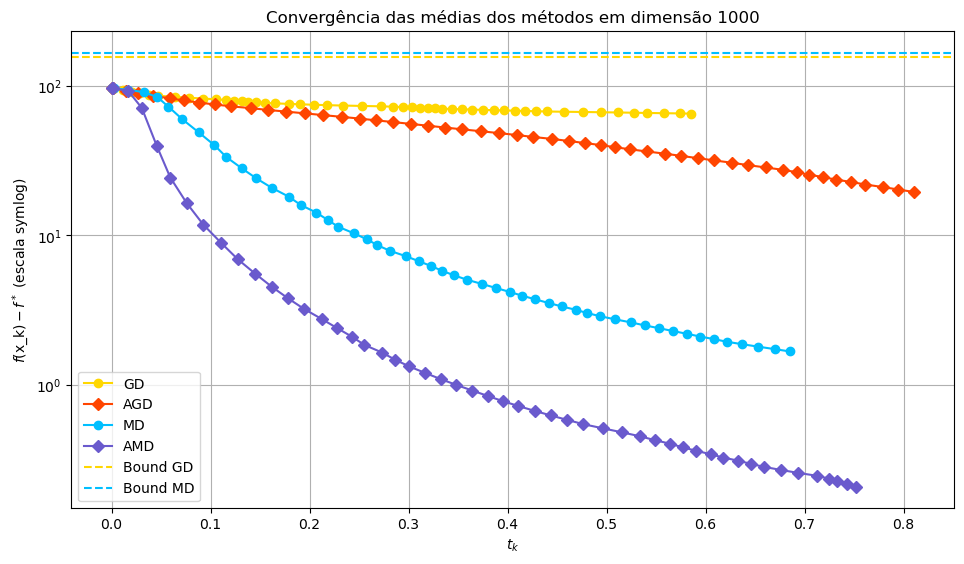

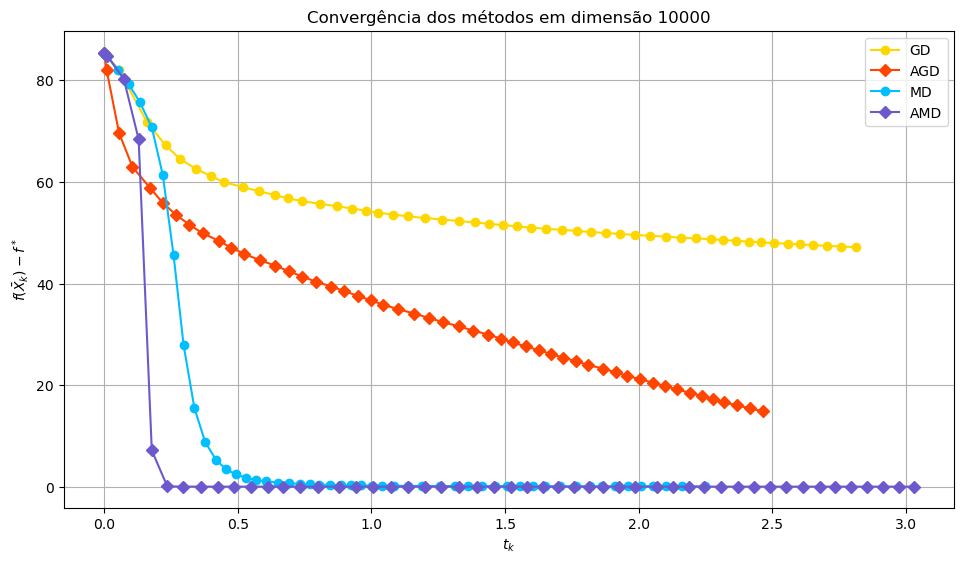

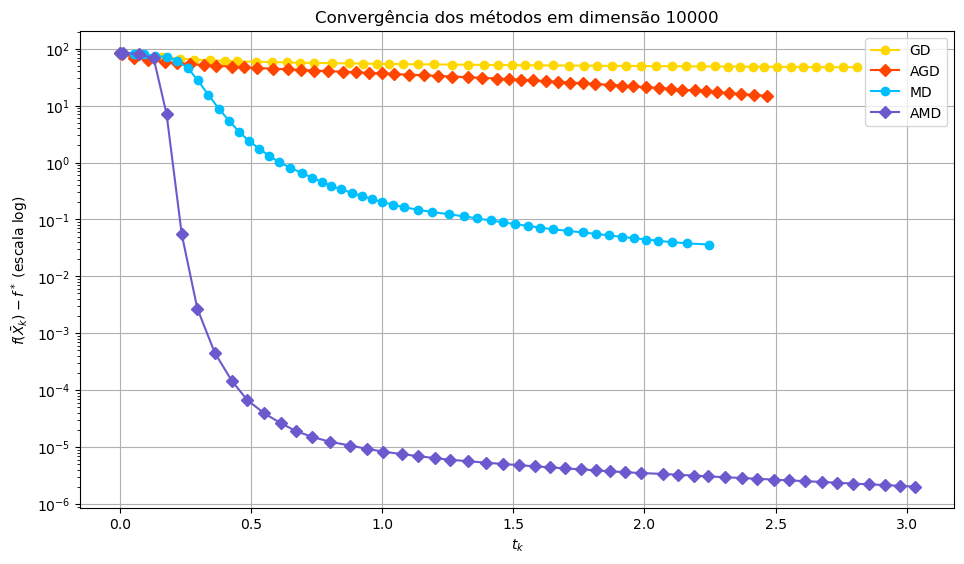

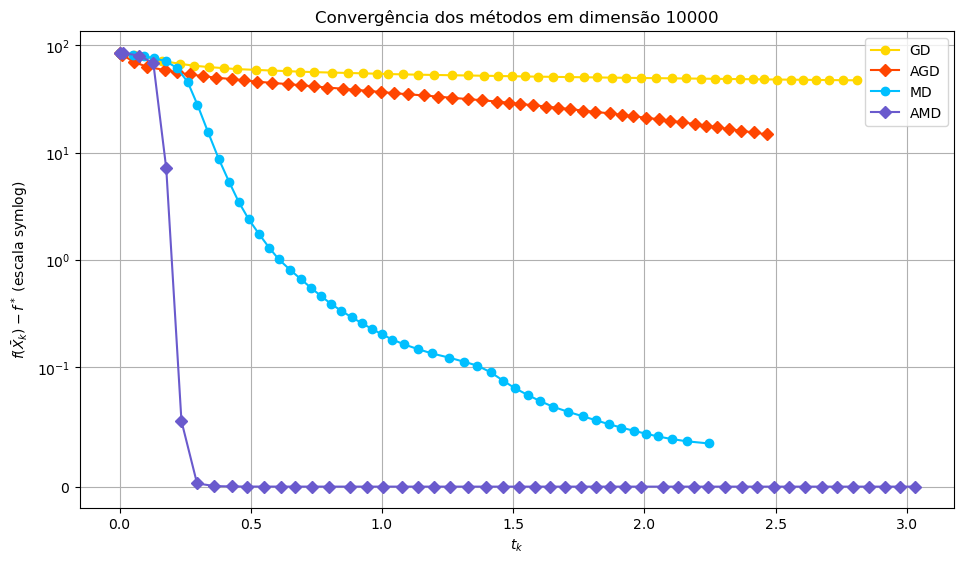

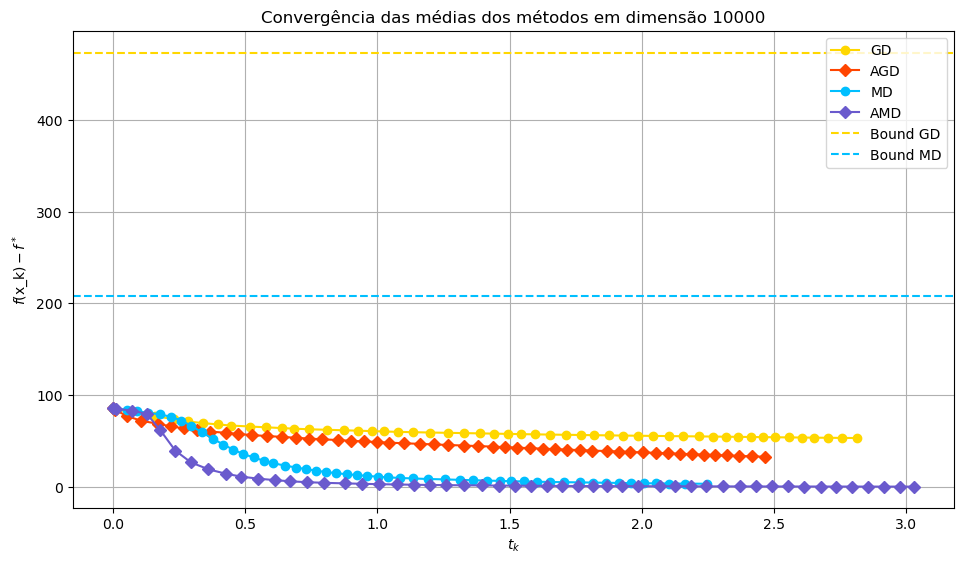

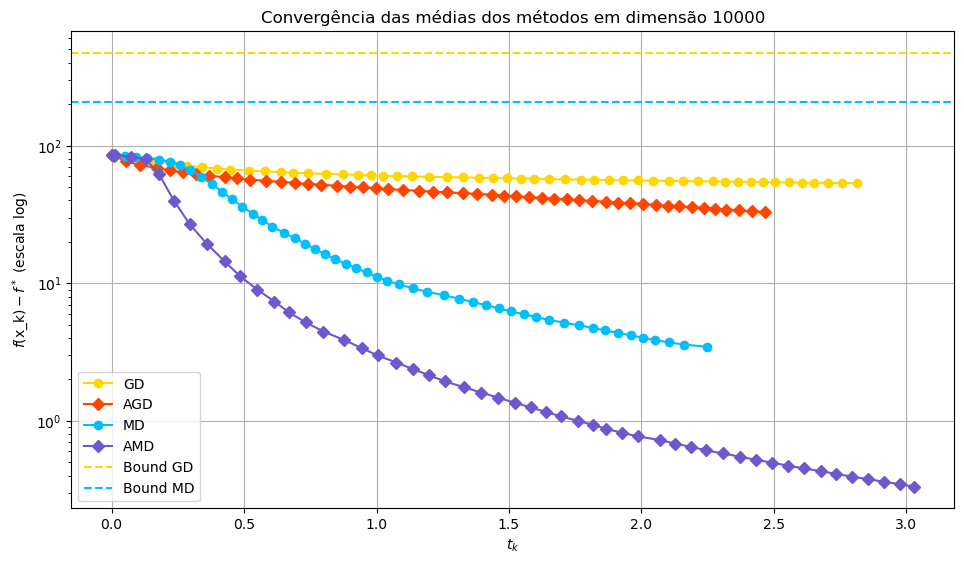

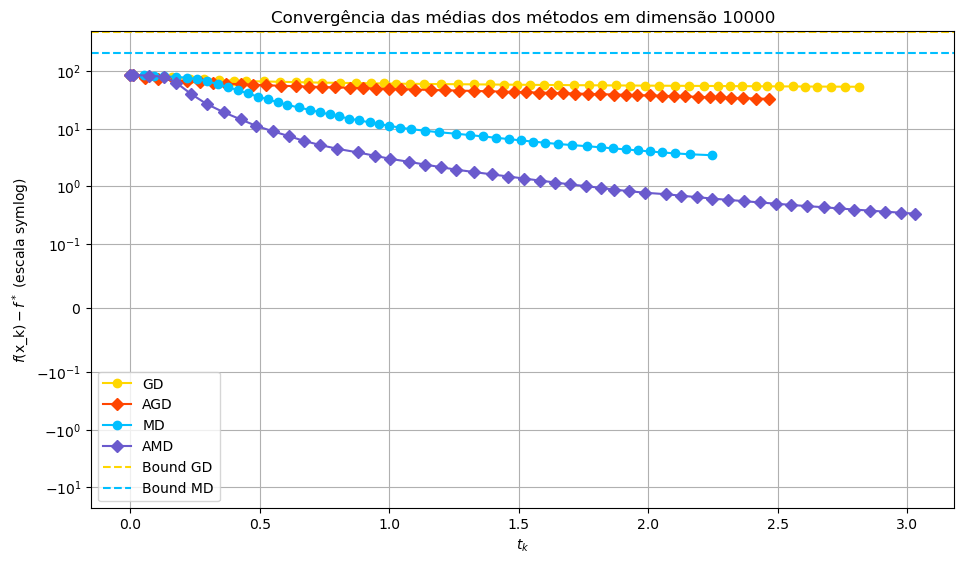

In [8]:
Dados = []
dados_casos={}
ns=[10, 100, 1000, 10000]

num_iter = 200
eta = 0.1

for n in ns:
    print(f"dimensão {n}")
    print()
    m = 100 # f: R^n -> R^m
    A = np.random.randn(m, n)
    x_true = np.zeros(n)
    x_true[np.random.randint(0,n-1)] = 1. #um vetor canônico (para ter esparcidade)
    b = A @ x_true #+ 0.01 * np.random.randn(m)
    
    sigma_max = np.linalg.norm(A, ord=2)
    L = 2 * sigma_max**2 #constante de Lipschitz de f, definida abaixo
    
    def f(x):
        return np.linalg.norm(A @ x - b)**2
    
    def grad_f(x):
        return 2 * A.T @ (A @ x - b)
    
    #print(f"Constante de Lipschitz para GD L= {L}")

    H = A.T @ A           # (n, n)
    c = A.T @ b           # (n,)
    
    # grad at vertex k: g_k = 2*(H[:,k] - c)
    # vamos construir matriz (n, n) cujas colunas são H[:,k]-c
    cols = H - c.reshape(-1,1)   # cada coluna k: H[:,k] - c
    grads = 2.0 * cols           # (n, n) -> coluna k = grad(e_k)
    
    # norms along columns:
    grad_norms_2 = np.linalg.norm(grads, axis=0)      # tamanho n
    grad_norms_inf = np.max(np.abs(grads), axis=0)   # tamanho n
    
    G2 = np.max(grad_norms_2)
    Ginf = np.max(grad_norms_inf)
    
    print(f"Constante de Lipschitz para GD: {G2}")
    print(f"Constante de Lipschitz para MD: {Ginf}")
    
    x0 = np.ones(n) / n
    non_zero = np.ones(n)*1e-12
    f_opt = f(x_true)
    [[eta_gd, eta_md, bound_gd, bound_md],[x_gd, xm_gd, tm_gd, dt_gd, dtm_gd],[x_agd, xm_agd, tm_agd, dt_agd, dtm_agd],[x_md, xm_md, tm_md, dt_md, dtm_md], [x_amd, xm_amd, tm_amd, dt_amd, dtm_amd]] = gera_todas_as_imgs_comparação(n, num_iter, x0, G2, Ginf)

    gera_tm_dt(0, 'normal', n, tm_gd, dt_gd, tm_agd, dt_agd, tm_md, dt_md, tm_amd, dt_amd)
    gera_tm_dt(0, 'log'   , n, tm_gd, dt_gd, tm_agd, dt_agd, tm_md, dt_md, tm_amd, dt_amd)
    gera_tm_dt(0, 'symlog', n, tm_gd, dt_gd, tm_agd, dt_agd, tm_md, dt_md, tm_amd, dt_amd)

    gera_tm_dt(1, 'normal', n, tm_gd, dtm_gd, tm_agd, dtm_agd, tm_md, dtm_md, tm_amd, dtm_amd, bound_gd, bound_md)
    gera_tm_dt(1, 'log'   , n, tm_gd, dtm_gd, tm_agd, dtm_agd, tm_md, dtm_md, tm_amd, dtm_amd, bound_gd, bound_md)
    gera_tm_dt(1, 'symlog', n, tm_gd, dtm_gd, tm_agd, dtm_agd, tm_md, dtm_md, tm_amd, dtm_amd, bound_gd, bound_md)
    print()

    Dados.append([[eta_gd, eta_md, bound_gd, bound_md],[x_gd, xm_gd, tm_gd, dt_gd, dtm_gd],[x_agd, xm_agd, tm_agd, dt_agd, dtm_agd],[x_md, xm_md, tm_md, dt_md, dtm_md], [x_amd, xm_amd, tm_amd, dt_amd, dtm_amd]])
    dados_casos[f"dim {n}"] = [[eta_gd, eta_md, bound_gd, bound_md],[x_gd, xm_gd, tm_gd, dt_gd, dtm_gd],[x_agd, xm_agd, tm_agd, dt_agd, dtm_agd],[x_md, xm_md, tm_md, dt_md, dtm_md], [x_amd, xm_amd, tm_amd, dt_amd, dtm_amd]]

In [9]:
dados_casos["dim 100"][4][3][-1]

4.50158182318608e-06

In [10]:
import pandas as pd

def salvar_dados_em_excel(dados, nome_arquivo="resultados.xlsx"):
    with pd.ExcelWriter(nome_arquivo, engine="openpyxl") as writer:
        for chave, valores in dados.items():
            # Extrair parâmetros
            eta_gd, eta_md, bound_gd, bound_md = valores[0]

            # Organizar em DataFrame separado
            df_parametros = pd.DataFrame({
                "Parâmetro": ["eta_gd", "eta_md", "bound_gd", "bound_md"],
                "Valor": [eta_gd, eta_md, bound_gd, bound_md]
            })

            # Agora os métodos (GD, AGD, MD, AMD)
            metodos = valores[1:]
            nomes_metodos = ["GD", "AGD", "MD", "AMD"]

            # Número de iterações
            n_iter = len(metodos[0][0])
            dicionario_colunas = {"iteração": list(range(n_iter))}

            for nome, (xs, xms, tms, dts, dtms) in zip(nomes_metodos, metodos):
                dicionario_colunas[f"{nome} - pontos"] = xs
                dicionario_colunas[f"{nome} - pontos médios"] = xms
                dicionario_colunas[f"{nome} - tempo de execução"] = tms
                dicionario_colunas[f"{nome} - distâncias em valores do ponto ao ótimo"] = dts
                dicionario_colunas[f"{nome} - distâncias em valores do ponto médio ao ótimo"] = dtms

            df_metodos = pd.DataFrame(dicionario_colunas)

            # Escrever na planilha
            startrow = 0
            df_parametros.to_excel(writer, sheet_name=chave, index=False, startrow=startrow)
            startrow += len(df_parametros) + 2  # pular linhas
            df_metodos.to_excel(writer, sheet_name=chave, index=False, startrow=startrow)

    print(f"Arquivo salvo em {nome_arquivo}")


In [11]:
salvar_dados_em_excel(dados_casos, nome_arquivo="resultados_comparação_convergências.xlsx")

Arquivo salvo em resultados_comparação_convergências.xlsx


### 